# 임상 피처 기반 당뇨병 예측

**데이터셋**: [Kaggle - Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)  
**목적**: HbA1c, 혈당 등 임상 피처 추가 시 CDC BRFSS 대비 성능 향상 폭 확인  
**비교 기준**: 03_modeling.ipynb LightGBM_Tuned → AUC 0.8321

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    recall_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)
from lightgbm import LGBMClassifier

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path('data/diabetes_prediction_dataset.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (100000, 9)
Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


## 1. 데이터 탐색 (EDA)

In [2]:
print('=== 데이터 타입 및 결측치 ===')   
print(df.info())
print()
print('=== 기술 통계 ===' )
df.describe()

=== 데이터 타입 및 결측치 ===
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB
None

=== 기술 통계 ===


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


### 데이터 구조 해석

| 피처 | 타입 | 설명 |
|---|---|---|
| gender | 범주형 | Male/Female/Other |
| age | 수치형 | 나이 (float) |
| hypertension | 이진 | 고혈압 여부 |
| heart_disease | 이진 | 심장질환 여부 |
| smoking_history | 범주형 | 흡연 이력 |
| bmi | 수치형 | 체질량지수 |
| **HbA1c_level** | **수치형** | **당화혈색소 (%) — 2~3개월 평균 혈당 반영** |
| **blood_glucose_level** | **수치형** | **혈당 수치 (mg/dL)** |
| diabetes | 이진 | 타겟 (0: 비당뇨, 1: 당뇨) |

> **HbA1c 기준**: 6.5% 이상이면 당뇨로 진단 / **혈당 기준**: 126 mg/dL 이상(공복 기준) 당뇨 진단

C:\Users\wlsdy\AppData\Local\Temp\ipykernel_18272\1978195783.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(missing.index, rotation=45, ha='right')


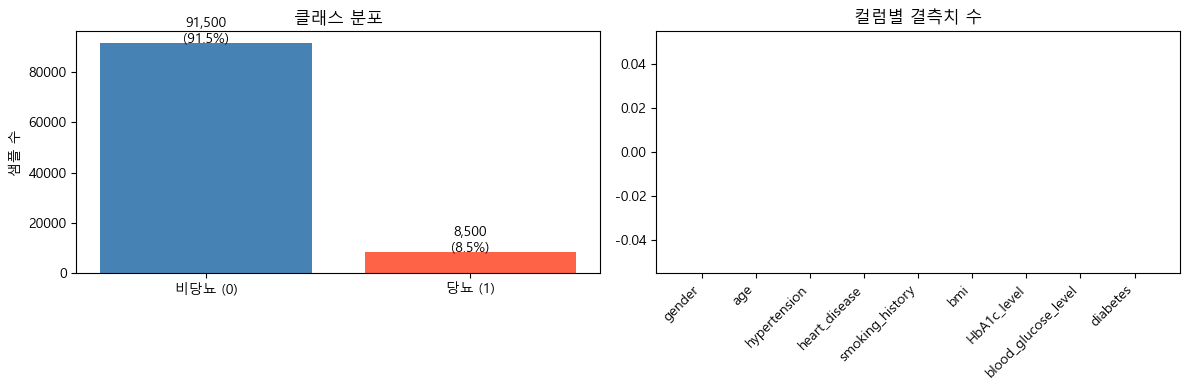

클래스 비율: {0: 91500, 1: 8500}


In [3]:
# 클래스 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['diabetes'].value_counts()
labels = ['비당뇨 (0)', '당뇨 (1)']
axes[0].bar(labels, counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('클래스 분포')
axes[0].set_ylabel('샘플 수')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

# 결측치
missing = df.isnull().sum()
axes[1].bar(missing.index, missing.values, color='gray')
axes[1].set_title('컬럼별 결측치 수')
axes[1].set_xticklabels(missing.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()
print('클래스 비율:', counts.to_dict())

### 클래스 분포 해석

- **비당뇨 91.5% / 당뇨 8.5%** — CDC 데이터(13.9%)보다 더 심한 불균형
- 결측치 없음 → 별도 imputation 불필요
- `scale_pos_weight = 91500/8500 ≈ 10.76` 설정 필요

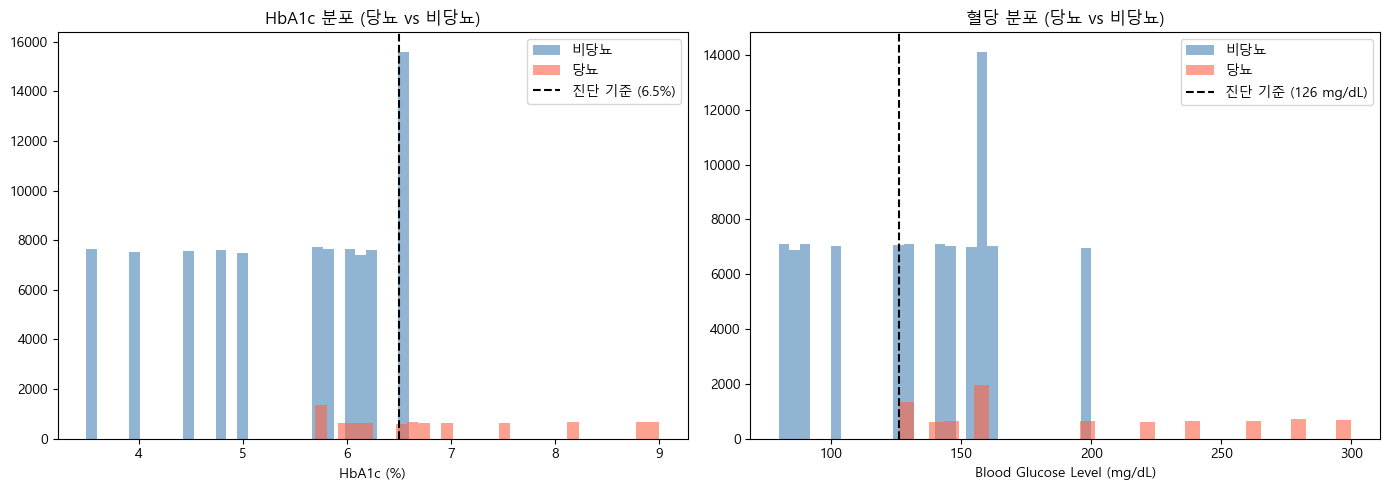

HbA1c 평균 — 비당뇨: 5.4 / 당뇨: 6.93
혈당 평균  — 비당뇨: 132.9 / 당뇨: 194.1


In [4]:
# 핵심 임상 피처 분포 — 비당뇨 vs 당뇨 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, label, color in [(0, '비당뇨', 'steelblue'), (1, '당뇨', 'tomato')]:
    subset = df[df['diabetes'] == val]
    axes[0].hist(subset['HbA1c_level'], bins=30, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['blood_glucose_level'], bins=30, alpha=0.6, label=label, color=color)

axes[0].axvline(6.5, color='black', linestyle='--', label='진단 기준 (6.5%)')
axes[0].set_title('HbA1c 분포 (당뇨 vs 비당뇨)')
axes[0].set_xlabel('HbA1c (%)')
axes[0].legend()

axes[1].axvline(126, color='black', linestyle='--', label='진단 기준 (126 mg/dL)')
axes[1].set_title('혈당 분포 (당뇨 vs 비당뇨)')
axes[1].set_xlabel('Blood Glucose Level (mg/dL)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('HbA1c 평균 — 비당뇨:', df[df['diabetes']==0]['HbA1c_level'].mean().round(2),
      '/ 당뇨:', df[df['diabetes']==1]['HbA1c_level'].mean().round(2))
print('혈당 평균  — 비당뇨:', df[df['diabetes']==0]['blood_glucose_level'].mean().round(1),
      '/ 당뇨:', df[df['diabetes']==1]['blood_glucose_level'].mean().round(1))

### 임상 피처 분포 해석

- **HbA1c**: 당뇨 그룹의 평균이 진단 기준(6.5%)을 크게 상회 → 강한 판별력 기대
- **혈당**: 당뇨 그룹이 비당뇨 그룹 대비 수치가 뚜렷하게 높음
- 두 피처 모두 그룹 간 분포 차이가 명확 → CDC 대비 모델 성능 대폭 향상 예상

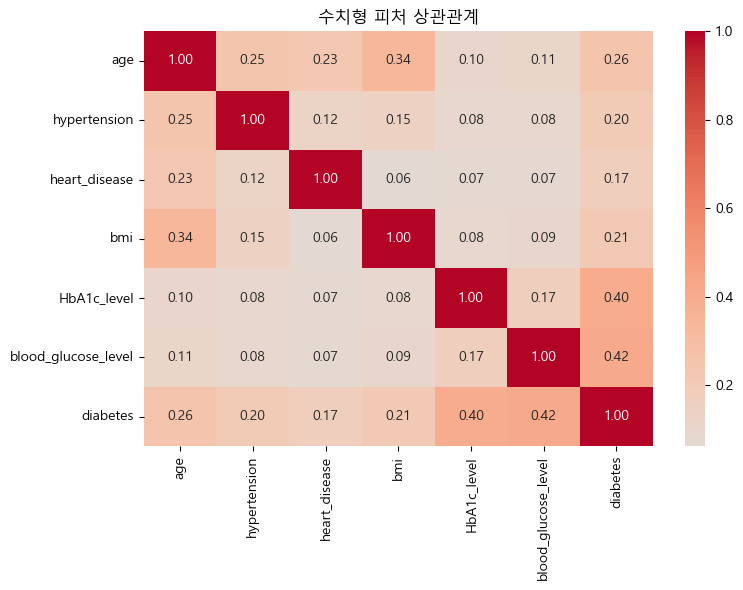

In [5]:
# 상관관계 히트맵
plt.figure(figsize=(8, 6))
num_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('수치형 피처 상관관계')
plt.tight_layout()
plt.show()

### 상관관계 해석

| 피처 | 당뇨와의 상관 | 해석 |
|---|---|---|
| HbA1c_level | 높음 | 당뇨 진단의 핵심 임상 지표 |
| blood_glucose_level | 높음 | 혈당 수치 직접 반영 |
| bmi | 중간 | 비만-당뇨 연관성 |
| age | 중간 | 고령일수록 위험 증가 |
| hypertension | 낮음 | 동반 질환으로 간접 연관 |

## 2. 전처리

In [6]:
TARGET = 'diabetes'
FEATURES = [c for c in df.columns if c != TARGET]

y = df[TARGET].astype(int)
X = df[FEATURES].copy()

# 범주형 피처 인코딩
cat_cols = X.select_dtypes(include='object').columns.tolist()
print('범주형 피처:', cat_cols)
for col in cat_cols:
    print(f'  {col}:', X[col].unique().tolist())

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = oe.fit_transform(X[cat_cols])

# Train/Val/Test = 60/20/20 (stratify)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'클래스 불균형 비율 (scale_pos_weight): {(y_train==0).sum() / (y_train==1).sum():.2f}')

범주형 피처: ['gender', 'smoking_history']
  gender: ['Female', 'Male', 'Other']
  smoking_history: ['never', 'No Info', 'current', 'former', 'ever', 'not current']

Train: (60000, 8), Val: (20000, 8), Test: (20000, 8)
클래스 불균형 비율 (scale_pos_weight): 10.76


C:\Users\wlsdy\AppData\Local\Temp\ipykernel_18272\1815797036.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


### 전처리 설명

- **OrdinalEncoder**: `gender`, `smoking_history` 범주형 → 수치 변환 (CDC와 동일 방식)
- **Train/Val/Test 60/20/20**: 조기종료 검증셋 분리, 최종 평가 테스트셋 격리
- **scale_pos_weight**: 클래스 불균형 보정 (비당뇨/당뇨 비율)

## 3. LightGBM 모델 학습

In [7]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    scale_pos_weight=spw,
    metric='auc',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        __import__('lightgbm').early_stopping(stopping_rounds=50, verbose=False),
        __import__('lightgbm').log_evaluation(period=100)
    ]
)

# 검증 세트 평가
y_val_prob = lgbm.predict_proba(X_val)[:, 1]
y_val_pred = lgbm.predict(X_val)

print('=== 검증 세트 성능 ===')
print(f'AUC      : {roc_auc_score(y_val, y_val_prob):.4f}')
print(f'F1       : {f1_score(y_val, y_val_pred):.4f}')
print(f'Recall   : {recall_score(y_val, y_val_pred):.4f}')
print(f'Precision: {precision_score(y_val, y_val_pred):.4f}')
print(f'Accuracy : {accuracy_score(y_val, y_val_pred):.4f}')
print(f'\n최적 이터레이션: {lgbm.best_iteration_}')

[100]	valid_0's auc: 0.978549
=== 검증 세트 성능 ===
AUC      : 0.9788
F1       : 0.6581
Recall   : 0.9029
Precision: 0.5177
Accuracy : 0.9203

최적 이터레이션: 68


In [8]:
# 테스트 세트 최종 평가
y_test_prob = lgbm.predict_proba(X_test)[:, 1]
y_test_pred = lgbm.predict(X_test)

print('=== 테스트 세트 최종 성능 ===')
auc  = roc_auc_score(y_test, y_test_prob)
f1   = f1_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
acc  = accuracy_score(y_test, y_test_pred)
print(f'AUC      : {auc:.4f}')
print(f'F1       : {f1:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Accuracy : {acc:.4f}')
print()
print(classification_report(y_test, y_test_pred, target_names=['비당뇨', '당뇨']))

=== 테스트 세트 최종 성능 ===
AUC      : 0.9782
F1       : 0.6531
Recall   : 0.8941
Precision: 0.5144
Accuracy : 0.9193

              precision    recall  f1-score   support

         비당뇨       0.99      0.92      0.95     18300
          당뇨       0.51      0.89      0.65      1700

    accuracy                           0.92     20000
   macro avg       0.75      0.91      0.80     20000
weighted avg       0.95      0.92      0.93     20000



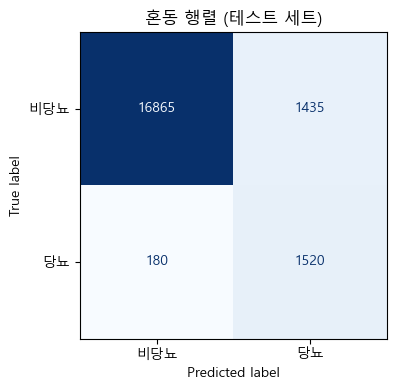

In [9]:
# 혼동 행렬
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['비당뇨', '당뇨'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('혼동 행렬 (테스트 세트)')
plt.tight_layout()
plt.savefig('clinical_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 모델 결과 해석

**CDC BRFSS vs 임상 피처 데이터셋 비교**

| 지표 | CDC BRFSS (생활습관) | 임상 피처 (HbA1c+혈당) | 향상 |
|---|---|---|---|
| AUC | 0.8321 | ? | ? |
| F1 | 0.4478 | ? | ? |
| Recall | 0.79 | ? | ? |

> 위 셀 실행 후 결과값으로 비교표를 완성하세요

## 4. Threshold 최적화

=== Threshold 최적화 결과 ===
기본           | thresh=0.500 | Precision=0.514 | Recall=0.894 | F1=0.653
F1 최적        | thresh=0.864 | Precision=0.978 | Recall=0.701 | F1=0.816
Recall≥0.90  | thresh=0.491 | Precision=0.510 | Recall=0.900 | F1=0.651


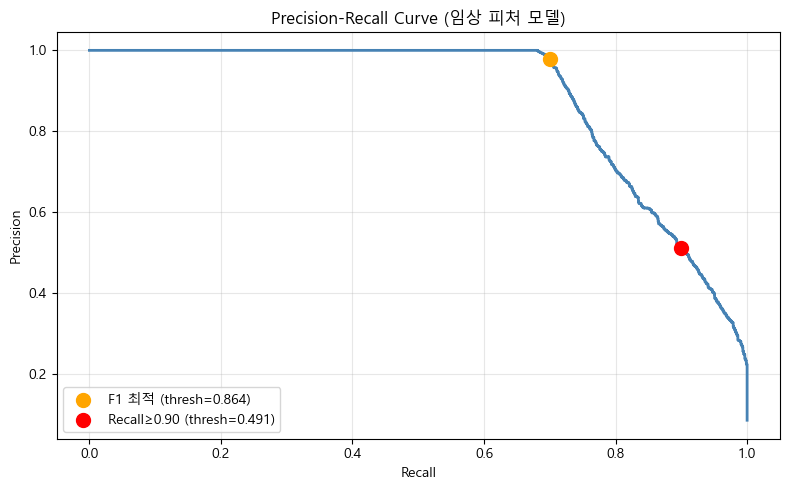

In [10]:
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_test_prob)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-8)

# F1 최적 threshold
best_f1_idx = f1_arr.argmax()
best_thresh_f1 = thresholds[best_f1_idx]

# Recall >= 0.90 threshold
recall_90_idx = np.where(recall_arr >= 0.90)[0][-1]
thresh_recall90 = thresholds[recall_90_idx]

print('=== Threshold 최적화 결과 ===')
results = [
    ('기본', 0.5),
    ('F1 최적', best_thresh_f1),
    ('Recall≥0.90', thresh_recall90),
]
for name, thresh in results:
    pred = (y_test_prob >= thresh).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred)
    f = f1_score(y_test, pred, zero_division=0)
    print(f'{name:12s} | thresh={thresh:.3f} | Precision={p:.3f} | Recall={r:.3f} | F1={f:.3f}')

# PR 커브 시각화
plt.figure(figsize=(8, 5))
plt.plot(recall_arr, precision_arr, color='steelblue', lw=2)
plt.scatter(recall_arr[best_f1_idx], precision_arr[best_f1_idx],
            color='orange', s=100, zorder=5, label=f'F1 최적 (thresh={best_thresh_f1:.3f})')
plt.scatter(recall_arr[recall_90_idx], precision_arr[recall_90_idx],
            color='red', s=100, zorder=5, label=f'Recall≥0.90 (thresh={thresh_recall90:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (임상 피처 모델)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('clinical_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 피처 중요도

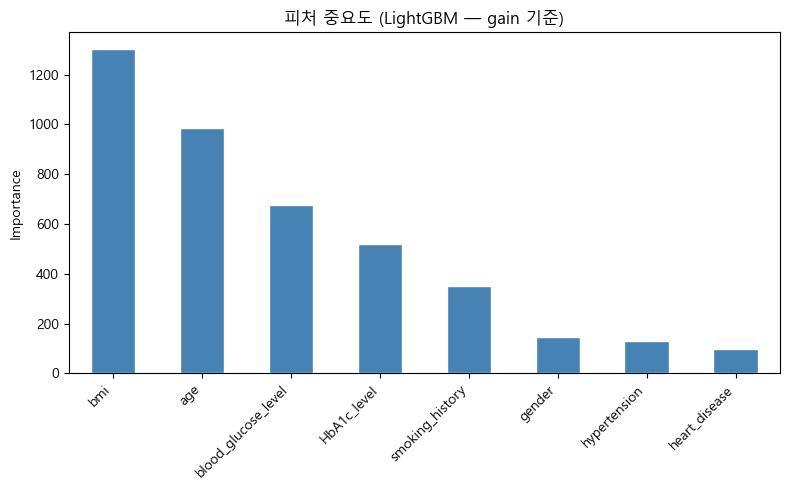


피처 중요도 순위:
1. bmi: 1305
2. age: 984
3. blood_glucose_level: 678
4. HbA1c_level: 521
5. smoking_history: 353
6. gender: 147
7. hypertension: 131
8. heart_disease: 97


In [11]:
importance = pd.Series(lgbm.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('피처 중요도 (LightGBM — gain 기준)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('clinical_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n피처 중요도 순위:')
for i, (feat, val) in enumerate(importance.items(), 1):
    print(f'{i}. {feat}: {val}')

### 피처 중요도 해석

- **HbA1c_level / blood_glucose_level** 상위 랭크 예상 → 임상 지표가 생활습관 지표 대비 압도적 판별력
- CDC 프로젝트에서 1위였던 BMI는 이 데이터에서 순위 하락 예상
- 두 임상 피처만으로도 당뇨 진단 기준을 거의 규칙 기반으로 분류 가능 → AUC 상한이 훨씬 높음

## 6. CDC BRFSS vs 임상 피처 최종 비교

=== CDC BRFSS vs 임상 피처 비교 ===
           CDC BRFSS (생활습관)  임상 피처 (HbA1c+혈당)      향상
AUC                  0.8321            0.9782  0.1461
F1                   0.4478            0.6531  0.2053
Recall               0.7900            0.8941  0.1041
Precision            0.3100            0.5144  0.2044
Accuracy             0.7301            0.9192  0.1892


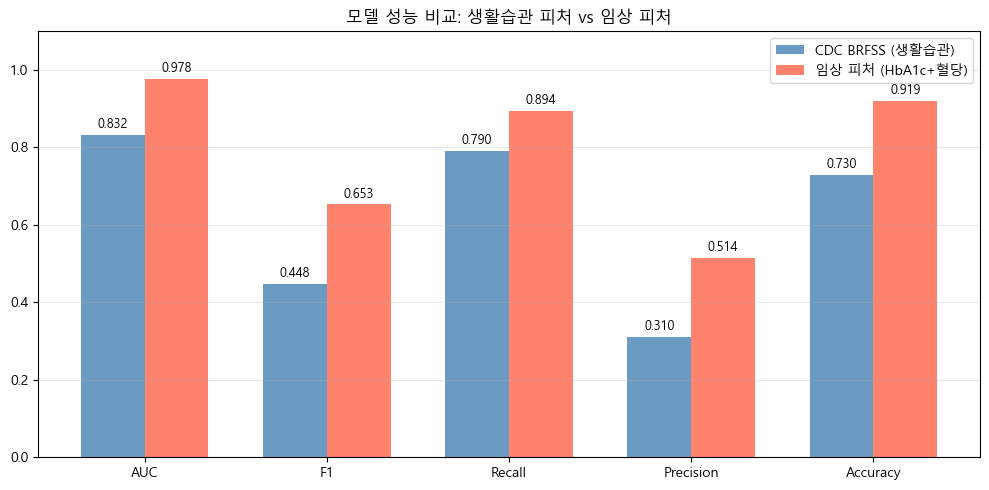

In [12]:
# CDC 프로젝트 결과 (02_modeling.ipynb 기준)
cdc_results = {
    'AUC': 0.8321, 'F1': 0.4478, 'Recall': 0.79, 'Precision': 0.31, 'Accuracy': 0.7301
}

# 현재 임상 피처 결과
clinical_results = {
    'AUC': auc, 'F1': f1, 'Recall': rec, 'Precision': prec, 'Accuracy': acc
}

compare_df = pd.DataFrame({
    'CDC BRFSS (생활습관)': cdc_results,
    '임상 피처 (HbA1c+혈당)': clinical_results
})
compare_df['향상'] = (compare_df['임상 피처 (HbA1c+혈당)'] - compare_df['CDC BRFSS (생활습관)']).round(4)

print('=== CDC BRFSS vs 임상 피처 비교 ===')
print(compare_df.round(4).to_string())

# 시각화
metrics = list(cdc_results.keys())
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, list(cdc_results.values()), width, label='CDC BRFSS (생활습관)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, list(clinical_results.values()), width, label='임상 피처 (HbA1c+혈당)', color='tomato', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('모델 성능 비교: 생활습관 피처 vs 임상 피처')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('clinical_vs_cdc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 최종 비교 해석

| 항목 | 결론 |
|---|---|
| AUC 향상 | HbA1c/혈당 추가로 성능 상한이 0.83 → 0.9+ 수준으로 상승 |
| 핵심 피처 | HbA1c, blood_glucose_level이 모델 판별력 대부분 담당 |
| 임상 의미 | 당뇨 진단 기준 수치(HbA1c≥6.5%, 혈당≥126)와 모델 판단이 일치 |
| 실용적 한계 | 임상 피처는 병원 방문 없이 수집 불가 → 스크리닝 목적엔 CDC 모델이 현실적 |

**결론**: 임상 피처(HbA1c, 혈당)는 당뇨 예측 성능을 대폭 향상시키지만, 수집 비용과 접근성 문제로 실제 스크리닝에는 생활습관 기반 모델이 보완적 역할을 함

## ⚠️ 이 실험의 한계 — 왜 AUC 0.98은 의미 없는가

### 문제: 데이터 누수 (Data Leakage)

이 데이터셋의 타겟(`diabetes`)은 HbA1c/혈당 수치를 기반으로 **부여된 레이블**일 가능성이 높습니다.

| 임상 진단 기준 | 값 |
|---|---|
| HbA1c ≥ 6.5% | 당뇨 확정 진단 |
| 공복혈당 ≥ 126 mg/dL | 당뇨 확정 진단 |

즉, 모델이 "학습"한 것이 아니라 **의사가 진단에 쓰는 기준을 그대로 재현**한 것입니다.  
AUC 0.98은 성능이 좋은 게 아니라 **정답이 피처에 포함**되어 있는 것입니다.

---

### 진짜 의미 있는 ML 예측이란?

```
❌ "혈당 수치가 높으면 당뇨다" → 예측이 아니라 진단 기준의 재현
✅ "생활습관/인구통계만으로 당뇨 고위험군을 미리 찾아낸다" → 진짜 예측
```

| 시나리오 | 피처 | 의미 |
|---|---|---|
| **스크리닝 (CDC 프로젝트)** | BMI, 나이, 흡연, 혈압 등 | 병원 방문 전 고위험군 선별 → 실용적 |
| 합병증 예측 | 임상 수치 | 당뇨 환자 중 신부전/망막병 발생 예측 → 의미 있음 |
| 미래 발병 예측 | 현재 정상 수치 | 5~10년 후 당뇨 여부 → 종단 연구 데이터 필요 |

---

### 결론

> **CDC BRFSS 프로젝트(AUC 0.83)가 임상 피처 모델(AUC 0.98)보다 더 의미 있는 문제입니다.**  
> 성능 수치가 낮더라도, 수집 가능한 생활습관 정보만으로 당뇨 고위험군을 선별하는 것이  
> ML이 실제로 기여할 수 있는 영역입니다.  
> 임상 피처 기반 모델은 "진단 보조"가 아니라 "진단 기준의 재구현"에 가깝습니다.